In [18]:
# Libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

In [19]:
# Parse docking results for new ligands
dir_at_cav = "swissdock_results\ligands"
dicc_ligands = {}
list_dicc = []
for dir in os.listdir(dir_at_cav):
    file_dock = dir_at_cav + "\\" + dir + "\\result.dock4"
    dicc_all = {}
    list_blocks = []
    block = 1
    with open(file_dock, "r") as f:
        for line in f:
            stripped_line = line.strip()
            list_blocks.append(stripped_line)

            if line.startswith('TER'):
                dicc_all[block] = list_blocks
                list_blocks = []
                block += 1
    if list_blocks:
        dicc_all[block] = list_blocks

    dicc_ligands[dir] = dicc_all

In [20]:
dir_outputs = "ligands_PDBs"
# Save the dock4 poses of the ligands as PDB files for visualization in PyMOL
if True:
    for key in dicc_ligands.keys():
        output = dir_outputs + "\\" + key + ".pdb"
        file_dock = dir_at_cav + "\\" + key + "\\result.dock4"
        with open(file_dock, "r") as infile, open(output, "w") as outfile:
            model = 1
            outfile.write(f"MODEL     {model}\n")
            for line in infile:
                if line.startswith("TER"):
                    outfile.write("ENDMDL\n")
                    model += 1
                    outfile.write(f"MODEL     {model}\n")
                elif line.startswith(("ATOM", "HETATM", "REMARK")):
                    outfile.write(line)
            outfile.write("ENDMDL\n")

In [21]:
# Parse SwissDock output files and extract docking metadata and atomic coordinates
dicc_remarks_master = {}
dicc_coords_master = {}
dicc_frames = {}
for ligand in dicc_ligands.keys():
    dicc_remarks = {}
    dicc_coords = {}
    for key in dicc_ligands[ligand].keys():
        new_key = dicc_ligands[ligand][key][0].split(' ')[-1]
        new_key = new_key.split('.')[0]
        dicc_frames[ligand + '_' + new_key] = key
        dicc_remarks[new_key] = {}
        dicc_coords[new_key] = []
        for elem in dicc_ligands[ligand][key]:
            if 'REMARK' in elem:
                elem_parts = elem.split()
                field = elem_parts[1]
                value = elem_parts[-1]
                dicc_remarks[new_key][field] = value
            elif 'ATOM' in elem:
                dicc_coords[new_key].append(elem)
    dicc_remarks_master[ligand] = dicc_remarks
    dicc_coords_master[ligand] = dicc_coords

In [22]:
# Build a DataFrame containing docking scores and metadata for all ligand poses
dfs = []

for ligand, dicc in dicc_remarks_master.items():
    df = pd.DataFrame.from_dict(dicc, orient='index')
    df["ligand"] = ligand
    dfs.append(df)

df_remarks = pd.concat(dfs, ignore_index=True)

df_remarks[['MEMBER_ENERGY', 'MEMBER_SCORE', 'SP-dG', 'Polar', 
            'Nonpolar', 'Inter', 'Polar15', 'RMSD']] = \
    df_remarks[['MEMBER_ENERGY', 'MEMBER_SCORE', 'SP-dG', 'Polar',
                'Nonpolar', 'Inter', 'Polar15', 'RMSD']].astype(float)

df_remarks[['CLUSTER_NUM', 'CLUSTER_MEMBER']] = \
    df_remarks[['CLUSTER_NUM', 'CLUSTER_MEMBER']].astype(int)

# Assign the corresponding frame number to each docking pose
df_remarks['frame'] = np.nan
df_remarks['seed'] = pd.Series(dtype='string')
for index, row in df_remarks.iterrows():
    seed = row['FILE_NAME'].split('.')[0]
    df_remarks.loc[index, 'seed'] = seed
    ligand = row['ligand']
    frame_key = ligand + '_' + seed
    frame = dicc_frames[frame_key]
    df_remarks.loc[index, 'frame'] = frame

df_remarks['frame'] = df_remarks['frame'].astype(int)

In [23]:
# Convert atomic coordinates into DataFrames for each ligand pose
cols = [
    "record_name", "atom_serial", "atom_name",
    "residue_name", "residue_number",
    "x", "y", "z",
    "occupancy", "b_factor", "segment_id"
]

for ligand in dicc_coords_master.keys():
    for key in dicc_coords_master[ligand].keys():
        atom_data = []
        for line in dicc_coords_master[ligand][key]:
            values = line.split()
            atom_info = {
                "record_name": values[0],
                "atom_serial": int(values[1]),
                "atom_name": values[2],
                "residue_name": values[3],
                "residue_number": int(values[4]),
                "x": float(values[5]),
                "y": float(values[6]),
                "z": float(values[7]),
                "occupancy": float(values[8]),
                "b_factor": float(values[9]),
                "segment_id": values[10]
                }
            atom_data.append(atom_info)
            dicc_coords_master[ligand][key] = pd.DataFrame(atom_data)

In [24]:
# Protein
df_coords_prot = pd.read_csv("protein_coords.csv")

In [25]:
# Identify the top 15% of docking poses based on SP-dG score
df_remarks_top_pct = df_remarks.copy()
n_total = df_remarks_top_pct.shape[0]
n_top_pct = int(n_total * 0.15)
df_remarks_top_pct = df_remarks_top_pct.sort_values(by='SP-dG')
df_remarks_top_pct = df_remarks_top_pct.head(n_top_pct)

In [26]:
# Parse docking results for new ligands
dir_at_cav = "swissdock_results\\new_candidates"
dicc_new_ligands = {}
list_dicc = []
for dir in os.listdir(dir_at_cav):
    file_dock = dir_at_cav + "\\" + dir + "\\result.dock4"
    dicc_all = {}
    list_blocks = []
    block = 1
    with open(file_dock, "r") as f:
        for line in f:
            stripped_line = line.strip()
            list_blocks.append(stripped_line)

            if line.startswith('TER'):
                dicc_all[block] = list_blocks
                list_blocks = []
                block += 1
    if list_blocks:
        dicc_all[block] = list_blocks

    dicc_new_ligands[dir] = dicc_all


In [27]:
# Save the dock4 poses of the new ligands as PDB files
dir_outputs_cand = "ligands_PDBs"

if True:
    for key in dicc_new_ligands.keys():
        output = dir_outputs_cand + "\\" + key + ".pdb"
        file_dock = dir_at_cav + "\\" + key + "\\result.dock4"
        with open(file_dock, "r") as infile, open(output, "w") as outfile:
            model = 1
            outfile.write(f"MODEL     {model}\n")
            for line in infile:
                if line.startswith("TER"):
                    outfile.write("ENDMDL\n")
                    model += 1
                    outfile.write(f"MODEL     {model}\n")
                elif line.startswith(("ATOM", "HETATM", "REMARK")):
                    outfile.write(line)
            outfile.write("ENDMDL\n")

In [28]:
# Extract docking metadata and atomic coordinates for new ligands
dicc_remarks_master_new = {}
dicc_coords_master_new = {}
dicc_frames_new = {}
for ligand in dicc_new_ligands.keys():
    dicc_remarks = {}
    dicc_coords = {}
    for key in dicc_new_ligands[ligand].keys():
        new_key = dicc_new_ligands[ligand][key][0].split(' ')[-1]
        new_key = new_key.split('.')[0]
        dicc_frames_new[ligand + '_' + new_key] = key
        dicc_remarks[new_key] = {}
        dicc_coords[new_key] = []
        for elem in dicc_new_ligands[ligand][key]:
            if 'REMARK' in elem:
                elem_parts = elem.split()
                field = elem_parts[1]
                value = elem_parts[-1]
                dicc_remarks[new_key][field] = value
            elif 'ATOM' in elem:
                dicc_coords[new_key].append(elem)
    dicc_remarks_master_new[ligand] = dicc_remarks
    dicc_coords_master_new[ligand] = dicc_coords

In [29]:
# Build a DataFrame containing docking scores and metadata for all new ligand poses
dfs = []

for ligand, dicc in dicc_remarks_master_new.items():
    df = pd.DataFrame.from_dict(dicc, orient='index')
    df["ligand"] = ligand
    dfs.append(df)

df_remarks_new = pd.concat(dfs, ignore_index=True)

df_remarks_new[['MEMBER_ENERGY', 'MEMBER_SCORE', 'SP-dG', 'Polar', 
            'Nonpolar', 'Inter', 'Polar15', 'RMSD']] = \
    df_remarks_new[['MEMBER_ENERGY', 'MEMBER_SCORE', 'SP-dG', 'Polar',
                'Nonpolar', 'Inter', 'Polar15', 'RMSD']].astype(float)

df_remarks_new[['CLUSTER_NUM', 'CLUSTER_MEMBER']] = \
    df_remarks_new[['CLUSTER_NUM', 'CLUSTER_MEMBER']].astype(int)

df_remarks_new['frame'] = np.nan
df_remarks_new['seed'] = pd.Series(dtype='string')
for index, row in df_remarks_new.iterrows():
    seed = row['FILE_NAME'].split('.')[0]
    df_remarks_new.loc[index, 'seed'] = seed
    ligand = row['ligand']
    frame_key = ligand + '_' + seed
    frame = dicc_frames_new[frame_key]
    df_remarks_new.loc[index, 'frame'] = frame

df_remarks_new['frame'] = df_remarks_new['frame'].astype(int)

In [30]:
# Convert atomic coordinates into DataFrames for each new ligand pose
cols = [
    "record_name", "atom_serial", "atom_name",
    "residue_name", "residue_number",
    "x", "y", "z",
    "occupancy", "b_factor", "segment_id"
]

for ligand in dicc_coords_master_new.keys():
    for key in dicc_coords_master_new[ligand].keys():
        atom_data = []
        for line in dicc_coords_master_new[ligand][key]:
            values = line.split()
            atom_info = {
                "record_name": values[0],
                "atom_serial": int(values[1]),
                "atom_name": values[2],
                "residue_name": values[3],
                "residue_number": int(values[4]),
                "x": float(values[5]),
                "y": float(values[6]),
                "z": float(values[7]),
                "occupancy": float(values[8]),
                "b_factor": float(values[9]),
                "segment_id": values[10]
                }
            atom_data.append(atom_info)
            dicc_coords_master_new[ligand][key] = pd.DataFrame(atom_data)

In [31]:
# Identify the top 10 docking poses for each new ligand based on SP-dG score
df_remarks_new_top_ten = df_remarks_new.copy()
df_remarks_new_top_ten = df_remarks_new_top_ten.sort_values(by='SP-dG')
df_remarks_new_top_ten = df_remarks_new_top_ten.groupby("ligand").head(10)

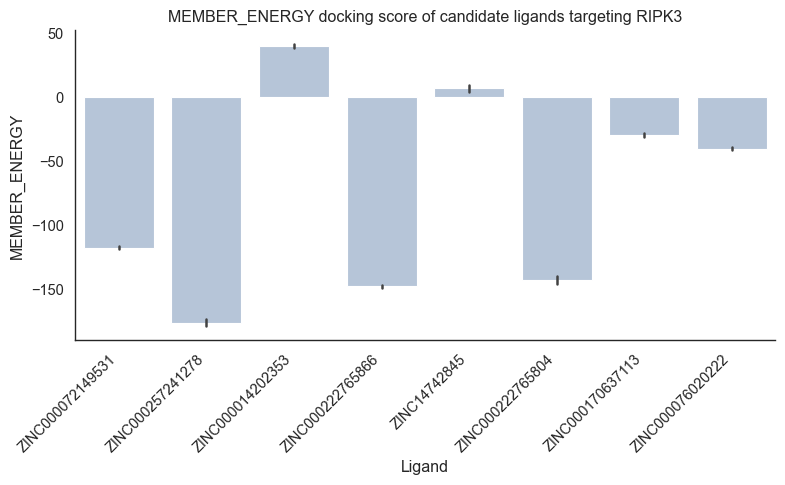

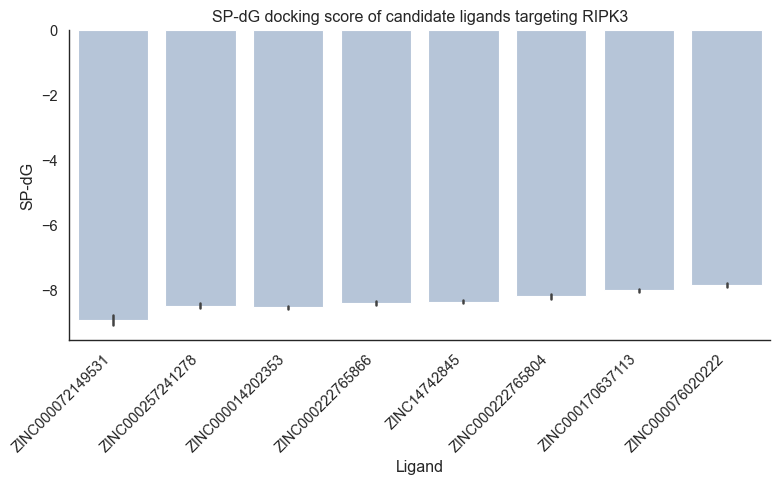

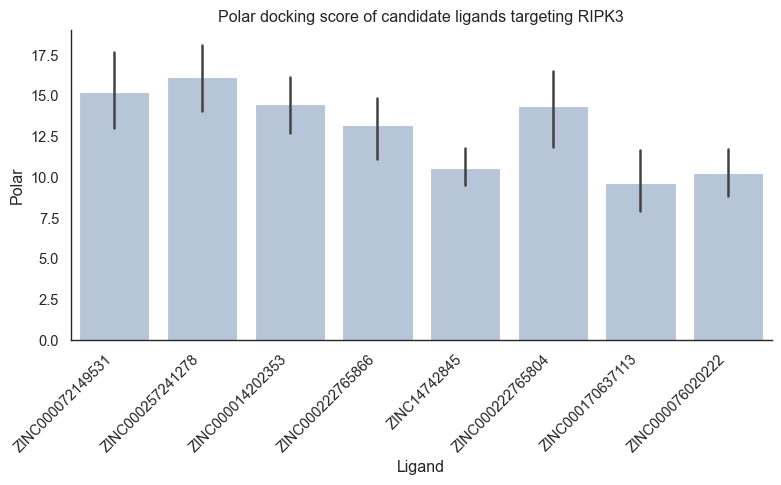

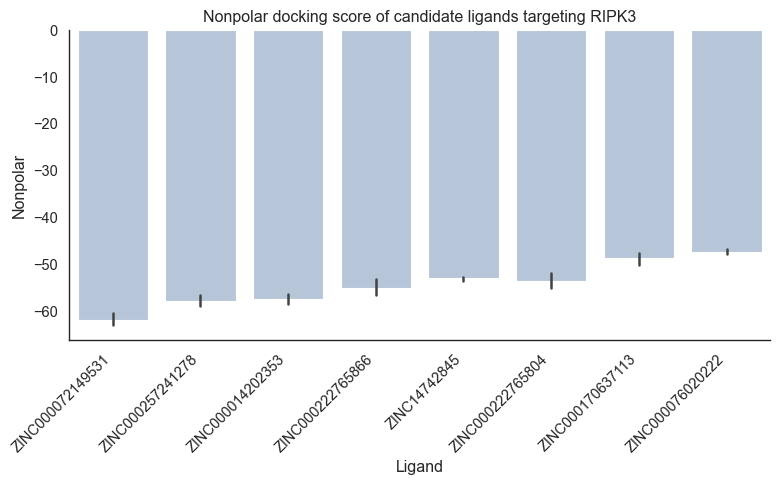

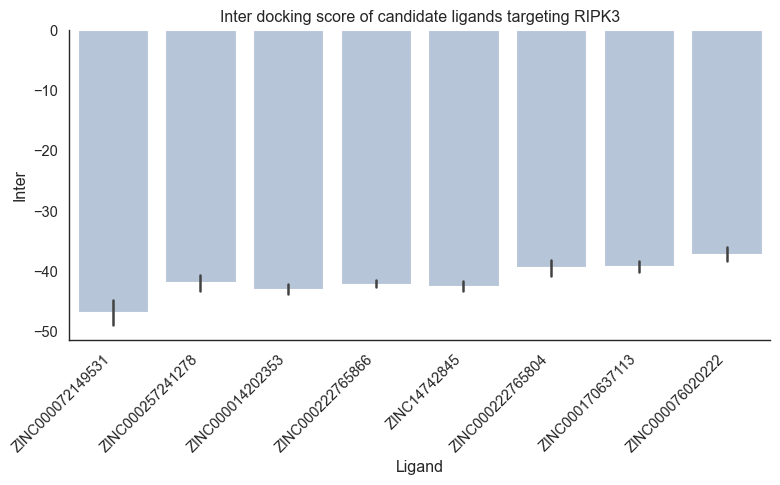

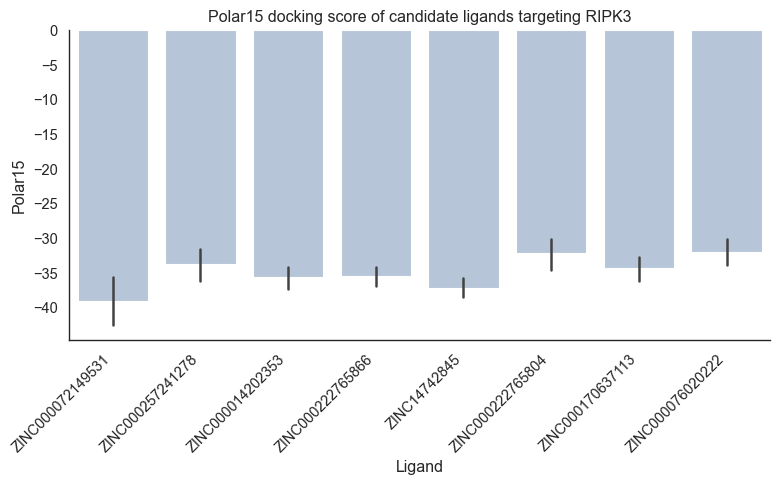

In [32]:
# Visualize the docking scores of the top 10 candidate ligands
sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2
)

df_plot = df_remarks_new_top_ten.sort_values("SP-dG", ascending=True)

energy_cols = ['MEMBER_ENERGY', 'SP-dG', 'Polar', 'Nonpolar', 'Inter', 'Polar15']

for prop in energy_cols:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df_plot,
        x="ligand",
        y=prop,
        color="lightsteelblue"
    )

    plt.ylabel(f"{prop}")
    plt.xlabel("Ligand")
    plt.title(f"{prop} docking score of candidate ligands targeting RIPK3")

    plt.xticks(rotation=45, ha="right")

    sns.despine()

    plt.tight_layout()
    plt.savefig(f"figures\\{prop}_candidates_ligands.png", dpi=300)
    plt.show()

In [33]:
# Select the best pose for each new ligand from the top 10 based on SP-dG score
df_remarks_new_top = df_remarks_new_top_ten.copy()
df_remarks_new_top = df_remarks_new_top.drop_duplicates(subset='ligand')

In [34]:
df_remarks_top_per_ligand = pd.read_csv('df_remarks_top_per_ligand.csv')

In [38]:
# Define a threshold distance for identifying contacts between ligand and receptor atoms
THR = 2.25

coords_receptor = df_coords_prot[['x','y','z']].to_numpy()
tree_receptor = cKDTree(coords_receptor)

In [39]:
# Identify contacts between ligand and receptor atoms for the top docking poses of each flavonoid
contacts = {}

for ligand in dicc_coords_master.keys():
    contacts[ligand] = []
    ligand_contacts = []

    df_temp = df_remarks_top_per_ligand[df_remarks_top_per_ligand['ligand'] == ligand]
    if df_temp.empty:
        print("No seed info for", ligand)
        continue

    for filename in df_temp['FILE_NAME'].unique():
        df_temp_seed = df_temp[df_temp['FILE_NAME']==filename]
        seed = df_temp_seed['FILE_NAME'].iloc[0].split('.')[0]
        frame = int(df_temp_seed['frame'].iloc[0])

        df_lig = dicc_coords_master[ligand].get(seed)
        if df_lig is None:
            print("No coords for", ligand, seed)
            continue

        coords_lig = df_lig[['x','y','z']].to_numpy()

        neigh_indices = tree_receptor.query_ball_point(coords_lig, r=THR)
        
        for i_lig, rec_idx_list in enumerate(neigh_indices):
            if not rec_idx_list:
                continue

            coord_l = coords_lig[i_lig]
            for j_rec in rec_idx_list:
                coord_r = coords_receptor[j_rec]
                d = np.linalg.norm(coord_l - coord_r)
                row_lig = df_lig.iloc[i_lig]
                row_rec = df_coords_prot.iloc[j_rec]
                rec_res_name = str(row_rec['residue_name'])
                rec_res_numb = str(int(row_rec['residue_number']))
                rec_res = rec_res_name + '`' + rec_res_numb
                ligand_contacts.append({
                    'ligand': ligand,
                    'seed': seed,
                    'frame': frame,
                    'lig_atom_name': row_lig['atom_name'],
                    'rec_res_name' : rec_res,
                    'rec_atom_name': row_rec['atom_name'],
                    'rec_segment_id': row_rec['segment_id'],
                    'distance': float(d),
                    'rec_res_numb': rec_res_numb
                })
    contacts[ligand] = ligand_contacts
    print(f"{ligand}: found {len(ligand_contacts)} pairs within {THR} Å")

Baicalein: found 2 pairs within 2.25 Å
Baicalin: found 9 pairs within 2.25 Å
Chrysin: found 2 pairs within 2.25 Å
Farrerol: found 10 pairs within 2.25 Å
Isoorientin: found 4 pairs within 2.25 Å
Myricetin: found 3 pairs within 2.25 Å
Phlorizin: found 6 pairs within 2.25 Å
Robinetin: found 3 pairs within 2.25 Å
Scutellarein: found 5 pairs within 2.25 Å
Tricetin: found 4 pairs within 2.25 Å


In [40]:
# Build a DataFrame containing all identified contacts between flavonoids and receptor atoms
all_rows = []
for ligand, lista_pares in contacts.items():
    all_rows.extend(lista_pares)

df_bonds = pd.DataFrame(all_rows)

In [41]:
file_prot = "swissdock_results\\receptor.pdb"

In [42]:
# Generate PyMOL scripts for visualizing ligand-receptor contacts
if True:
    output_folder_pml = "PyMOL_scripts"
    output_folder_png = "figures"

    command_open_prot = f'load ../{file_prot}, receptor'
    for ligand in df_bonds['ligand'].unique():
        df_temp = df_bonds[df_bonds['ligand'] == ligand]
        frame = df_temp['frame'].iloc[0]
        output_pml = output_folder_pml + '\\' + ligand + '.pml'
        dir_ligand = dir_outputs + "\\" + ligand + ".pdb"
        dir_png = output_folder_png + '\\' + ligand + '.png'
        bond_number = 0
        with open(output_pml, "w") as f:
            f.write(f'{command_open_prot}\n')
            f.write(f'load ../{dir_ligand}, {ligand}\n')
            f.write(f'util.cba(33,"receptor",_self=cmd)\n')
            f.write(f'space cmyk\n')
            f.write(f'cmd.color_deep("gray80", "receptor", 0)\n')
            f.write(f'set cartoon_transparency, 0.8\n')
            for _, row in df_temp.iterrows():
                lig_atom = row['lig_atom_name']
                rec_res = row['rec_res_name']
                rec_atom = row['rec_atom_name']
                rec_segment = row['rec_segment_id']
                rec_res_numb = row['rec_res_numb']
                rec_res_command = f'/receptor/{rec_segment}//{rec_res}'
                bond_number += 1
                bond_number_string = str(bond_number)
                f.write(f'distance d{bond_number_string}, {rec_res_command}/{rec_atom}, {ligand}/LIG//LIG`1/{lig_atom}, state={frame}\n')
                f.write(f'cmd.show("sticks", "{rec_res_command}")\n')
                f.write(f'util.cnc("{rec_res_command}",_self=cmd)\n')
                f.write(f'set stick_radius, 0.25, receptor and resi {rec_res_numb}\n')
                f.write(f'label receptor and resi {rec_res_numb} and name CA, "%s%s" % (resn, resi)\n')
            f.write(f'frame {frame}\n')
            f.write(f'set label_size, 18\n')
            f.write(f'set label_color, black\n')
            f.write(f'set opaque_background, 0\n')
            f.write(f'png ../{dir_png}, 0, 0, -1, ray=1')

In [43]:
# Identify contacts between ligand and receptor atoms for the top docking poses of each ligand candidate
contacts_new = {}

for ligand in dicc_coords_master_new.keys():
    df_temp = df_remarks_new_top[df_remarks_new_top['ligand'] == ligand]
    if df_temp.empty:
        print("No seed info for", ligand)
        continue
    seed = df_temp['FILE_NAME'].iloc[0].split('.')[0]
    frame = int(df_temp['frame'].iloc[0])

    df_lig = dicc_coords_master_new[ligand].get(seed)
    if df_lig is None:
        print("No coords for", ligand, seed)
        continue

    coords_lig = df_lig[['x','y','z']].to_numpy()

    neigh_indices = tree_receptor.query_ball_point(coords_lig, r=THR)
    
    ligand_contacts = []
    for i_lig, rec_idx_list in enumerate(neigh_indices):
        if not rec_idx_list:
            continue

        coord_l = coords_lig[i_lig]
        for j_rec in rec_idx_list:
            coord_r = coords_receptor[j_rec]
            d = np.linalg.norm(coord_l - coord_r)

            row_lig = df_lig.iloc[i_lig]
            row_rec = df_coords_prot.iloc[j_rec]
            rec_res_name = str(row_rec['residue_name'])
            rec_res_numb = str(int(row_rec['residue_number']))
            rec_res = rec_res_name + '`' + rec_res_numb
            ligand_contacts.append({
                'ligand': ligand,
                'frame': frame,
                'lig_atom_name': row_lig['atom_name'],
                'rec_res_name' : rec_res,
                'rec_atom_name': row_rec['atom_name'],
                'rec_segment_id': row_rec['segment_id'],
                'distance': float(d),
                'rec_res_numb' : rec_res_numb
            })
    contacts_new[ligand] = ligand_contacts
    print(f"{ligand}: found {len(ligand_contacts)} pairs within {THR} Å")

ZINC000014202353: found 11 pairs within 2.25 Å
ZINC000072149531: found 7 pairs within 2.25 Å
ZINC000076020222: found 6 pairs within 2.25 Å
ZINC000170637113: found 2 pairs within 2.25 Å
ZINC000222765804: found 8 pairs within 2.25 Å
ZINC000222765866: found 7 pairs within 2.25 Å
ZINC000257241278: found 17 pairs within 2.25 Å
ZINC14742845: found 10 pairs within 2.25 Å


In [44]:
# Build a DataFrame containing all identified contacts between new ligands and receptor atoms
all_rows = []
for ligand, lista_pares in contacts_new.items():
    all_rows.extend(lista_pares)

df_bonds_new = pd.DataFrame(all_rows)

In [45]:
# Generate PyMOL scripts for visualizing ligand-receptor contacts for new ligands
if True:
    output_folder_pml = "PyMOL_scripts"
    output_folder_png = "figures"

    command_open_prot = f'load ../{file_prot}, receptor'
    for ligand in df_bonds_new['ligand'].unique():
        df_temp = df_bonds_new[df_bonds_new['ligand'] == ligand]
        frame = df_temp['frame'].iloc[0]
        output_pml = output_folder_pml + '\\' + ligand + '.pml'
        dir_ligand = dir_outputs_cand + "\\" + ligand + ".pdb"
        dir_png = output_folder_png + '\\' + ligand + '.png'
        bond_number = 0
        with open(output_pml, "w") as f:
            f.write(f'{command_open_prot}\n')
            f.write(f'load ../{dir_ligand}, {ligand}\n')
            f.write(f'util.cba(33,"receptor",_self=cmd)\n')
            f.write(f'space cmyk\n')
            f.write(f'cmd.color_deep("gray80", "receptor", 0)\n')
            f.write(f'set cartoon_transparency, 0.8\n')
            for _, row in df_temp.iterrows():
                lig_atom = row['lig_atom_name']
                rec_res = row['rec_res_name']
                rec_atom = row['rec_atom_name']
                rec_segment = row['rec_segment_id']
                rec_res_numb = row['rec_res_numb']
                rec_res_command = f'/receptor/{rec_segment}//{rec_res}'
                bond_number += 1
                bond_number_string = str(bond_number)
                f.write(f'distance d{bond_number_string}, {rec_res_command}/{rec_atom}, {ligand}/LIG//LIG`1/{lig_atom}, state={frame}\n')
                f.write(f'cmd.show("sticks", "{rec_res_command}")\n')
                f.write(f'util.cnc("{rec_res_command}",_self=cmd)\n')
                f.write(f'set stick_radius, 0.25, receptor and resi {rec_res_numb}\n')
                f.write(f'label receptor and resi {rec_res_numb} and name CA, "%s%s" % (resn, resi)\n')
            f.write(f'frame {frame}\n')
            f.write(f'set label_size, 18\n')
            f.write(f'set label_color, black\n')
            
            f.write(f'set opaque_background, 0\n')
            f.write(f'png ../{dir_png}, 0, 0, -1, ray=1')